<a href="https://colab.research.google.com/github/seanwu-bit/Automated-Regional-Impact-Auditor-ARIA-/blob/aria_7.0/Week10_ARIA_v7_0_%E5%90%B3%E6%81%95%E8%91%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 10 Homework: ARIA v7.0 — The All-Weather Auditor
**Case Study:** Hualien, Typhoon Fung-wong


## 🛠️ Step 0: Environment Setup & Dependencies
**Captain's Log:** 為了符合專業資料工程標準與作業 Reproducibility (可重現性) 的要求，我們首先建立環境變數設定區。
1. **GDAL 網路優化**：設定 HTTP Retry 與 VSI Cache，確保從雲端 (STAC) 串流巨量衛星影像時不會斷線。
2. **字型與視覺化設定**：動態下載並掛載 `NotoSansTC` (思源黑體)，解決 Colab 繪圖時中文顯示為方塊的已知問題。
3. **參數集中管理 (.env 概念)**：將 `SAR_THRESHOLD`、`NDWI_THRESHOLD` 等關鍵判定門檻宣告為系統環境變數，避免數值 Hard-code 在後續程式碼中，便於未來快速抽換與迭代。

In [77]:
# ==========================================
# [Step 0] Environment Setup & Dependencies
# ==========================================
# 1. 安裝必要套件
!pip install -q pystac_client stackstac scikit-learn rasterio rioxarray planetary_computer python-dotenv

import logging

# 屏蔽 rasterio._env 產生的煩人警告，只顯示真正的 Error
logging.getLogger("rasterio").setLevel(logging.ERROR)

import os, time, warnings
warnings.filterwarnings('ignore')

# 2. GDAL HTTP retry 穩定設定（同課堂 W8 規範）
os.environ.setdefault('GDAL_HTTP_MAX_RETRY', '5')
os.environ.setdefault('GDAL_HTTP_RETRY_DELAY', '2')
os.environ.setdefault('GDAL_HTTP_TIMEOUT', '60')
os.environ.setdefault('GDAL_HTTP_MULTIRANGE', 'YES')
os.environ.setdefault('GDAL_HTTP_MERGE_CONSECUTIVE_RANGES', 'YES')
os.environ.setdefault('VSI_CACHE', 'TRUE')
os.environ.setdefault('VSI_CACHE_SIZE', '1000000000')
os.environ.setdefault('CPL_VSIL_CURL_ALLOWED_EXTENSIONS', '.tif,.TIF,.tiff')

# 3. 匯入資料科學與空間分析套件
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
import rioxarray as rxr
import xarray as xr
import pystac_client
import planetary_computer as pc
import stackstac

# 匯入進階影像處理套件 (SAR 濾波與形態學清理)
from scipy.ndimage import median_filter, binary_opening
from skimage.measure import label
import seaborn as sns

# 4. 下載並強制掛載中文字型 (最穩定解法)
import urllib.request
import matplotlib.font_manager as fm

font_path = "NotoSansTC.otf"
font_url = "https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rc('font', family=prop.get_name())
plt.rcParams['axes.unicode_minus'] = False
sns.set_palette("husl")

# 5. 掛載 Google Drive 與建立輸出資料夾
from google.colab import drive
drive.mount('/content/drive')
OUTPUT_DIR = "/content/drive/MyDrive/GIS_data/Week10_class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 6. 初始化 STAC Catalog 連線
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=pc.sign_inplace,
)

# ──────────────────────────────────────────────────────────────────
# 7. 🎯 [作業要求] .env 參數集中管理區 (Professional Standards)
# ──────────────────────────────────────────────────────────────────
# 檔案與閾值設定 (參照作業規範)
os.environ['SAR_FILE'] = f'{OUTPUT_DIR}/S1_Hualien_dB.tif'
os.environ['SAR_THRESHOLD'] = '-18'     # ARIA 預設水體門檻
os.environ['NDWI_THRESHOLD'] = '0.0'    # 鳳凰颱風濁水環境門檻
os.environ['SLOPE_THRESHOLD'] = '25'    # 地形過濾坡度門檻

# 影像檢索參數 (Optical & SAR Collections)
os.environ['OPTICAL_COLLECTION'] = 'sentinel-2-l2a'
os.environ['SAR_COLLECTION'] = 'sentinel-1-rtc'
os.environ['DATETIME_RANGE'] = '2025-10-20/2025-11-20' # 鳳凰颱風期間

# 空間範圍設定 (BBOX - 依據老師作業說明提供之花蓮座標)
os.environ['BBOX_WEST']  = '121.28'
os.environ['BBOX_SOUTH'] = '23.56'
os.environ['BBOX_EAST']  = '121.52'
os.environ['BBOX_NORTH'] = '23.76'

print(f"✅ 環境建置與 .env 變數載入完成！")
print(f"  > SAR Threshold : {os.environ.get('SAR_THRESHOLD')} dB")
print(f"  > Datetime      : {os.environ.get('DATETIME_RANGE')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 環境建置與 .env 變數載入完成！
  > SAR Threshold : -18 dB
  > Datetime      : 2025-10-20/2025-11-20


## Task 1: SAR All-Weather Flood Detection (Cloud Streaming)
**Captain's Log:** 由於缺少預先處理好的本地 GeoTIFF 檔案，我們改採更進階的雲端串流策略。
直接透過 STAC API 檢索 `sentinel-1-rtc` (Radiometrically Terrain Corrected) 資料集，獲取與光學影像同時期 (2025/11) 的雷達影像。
1. **Cloud Streaming**：串流 `vv` 波段，並將線性回波強度轉換為對數的 dB 值 `10 * log10(vv)`。
2. **斑點濾波**：套用 `5x5 Median Filter` 進行平滑化去雜訊。
3. **水體切割**：使用預設的 `-18 dB` 進行二值化水體切割。
4. **形態學清理**：加入形態學開運算與連通體過濾，強制移除面積過小 (< 20 px) 的假水體。

In [78]:
# ==========================================
# [Task 1.0] SAR 影像檢索與軌道配對工具
# ==========================================
print("⏳ 正在搜尋花蓮區域 2025/10 - 2025/11 的 SAR 影像...")

# 設定搜尋範圍 (沿用 Step 0 的 BBOX)
TARGET_BBOX = [float(os.environ['BBOX_WEST']), float(os.environ['BBOX_SOUTH']),
               float(os.environ['BBOX_EAST']), float(os.environ['BBOX_NORTH'])]

# 搜尋時間拉長，以便找到災前 (Pre) 的對照組
search_sar = catalog.search(
    collections=['sentinel-1-rtc'],
    bbox=TARGET_BBOX,
    datetime="2025-10-20/2025-11-20"
)
items_sar = list(search_sar.items())

print("-" * 60)
print(f"{'Date':<12} | {'Direction':<10} | {'Orbit':<8} | {'Item ID'}")
print("-" * 60)

if items_sar:
    # 依日期排序
    items_sar.sort(key=lambda x: x.properties['datetime'])
    for it in items_sar:
        date = it.properties['datetime'][:10]
        direction = it.properties.get('sat:orbit_state', 'N/A')
        orbit = it.properties.get('sat:absolute_orbit', 'N/A')
        print(f"{date:<12} | {direction:<10} | {orbit:<8} | {it.id}")
else:
    print("⚠ 找不到符合條件的 SAR 影像。")

print("-" * 60)
print("💡 提示：請從上方清單選取一組災前 (Pre) 與一組災中 (Mid) 的 ID。")
print("   條件：兩者的 Orbit 必須相同，且 Direction 必須一致。")

⏳ 正在搜尋花蓮區域 2025/10 - 2025/11 的 SAR 影像...
------------------------------------------------------------
Date         | Direction  | Orbit    | Item ID
------------------------------------------------------------
2025-10-20   | descending | 4651     | S1C_IW_GRDH_1SDV_20251020T215122_20251020T215151_004651_00931F_rtc
2025-10-20   | descending | 4651     | S1C_IW_GRDH_1SDV_20251020T215151_20251020T215216_004651_00931F_rtc
2025-10-24   | ascending  | 61566    | S1A_IW_GRDH_1SDV_20251024T100123_20251024T100148_061566_07B06F_rtc
2025-10-26   | descending | 61602    | S1A_IW_GRDH_1SDV_20251026T215251_20251026T215316_061602_07B1DF_rtc
2025-10-30   | ascending  | 4790     | S1C_IW_GRDH_1SDV_20251030T100018_20251030T100043_004790_00975D_rtc
2025-11-01   | descending | 4826     | S1C_IW_GRDH_1SDV_20251101T215121_20251101T215151_004826_009893_rtc
2025-11-01   | descending | 4826     | S1C_IW_GRDH_1SDV_20251101T215151_20251101T215216_004826_009893_rtc
2025-11-05   | ascending  | 61741    | S1A_IW_GR

###註：考慮光學影像可用時間，挑選10/30、11/11(災害中)相同軌道方向(ascending)之SAR影像。

In [81]:
# ── 👉 請填入你挑選的相同軌道 ID ──
SAR_IDS = {
    'Pre': 'S1C_IW_GRDH_1SDV_20251101T215151_20251101T215216_004826_009893_rtc',
    'Mid': 'S1C_IW_GRDH_1SDV_20251113T215150_20251113T215215_005001_009E5E_rtc'
}

⏳ 正在處理變遷分析並進行 5x5 平滑濾波...
✅ 變遷偵測與平滑處理完成。


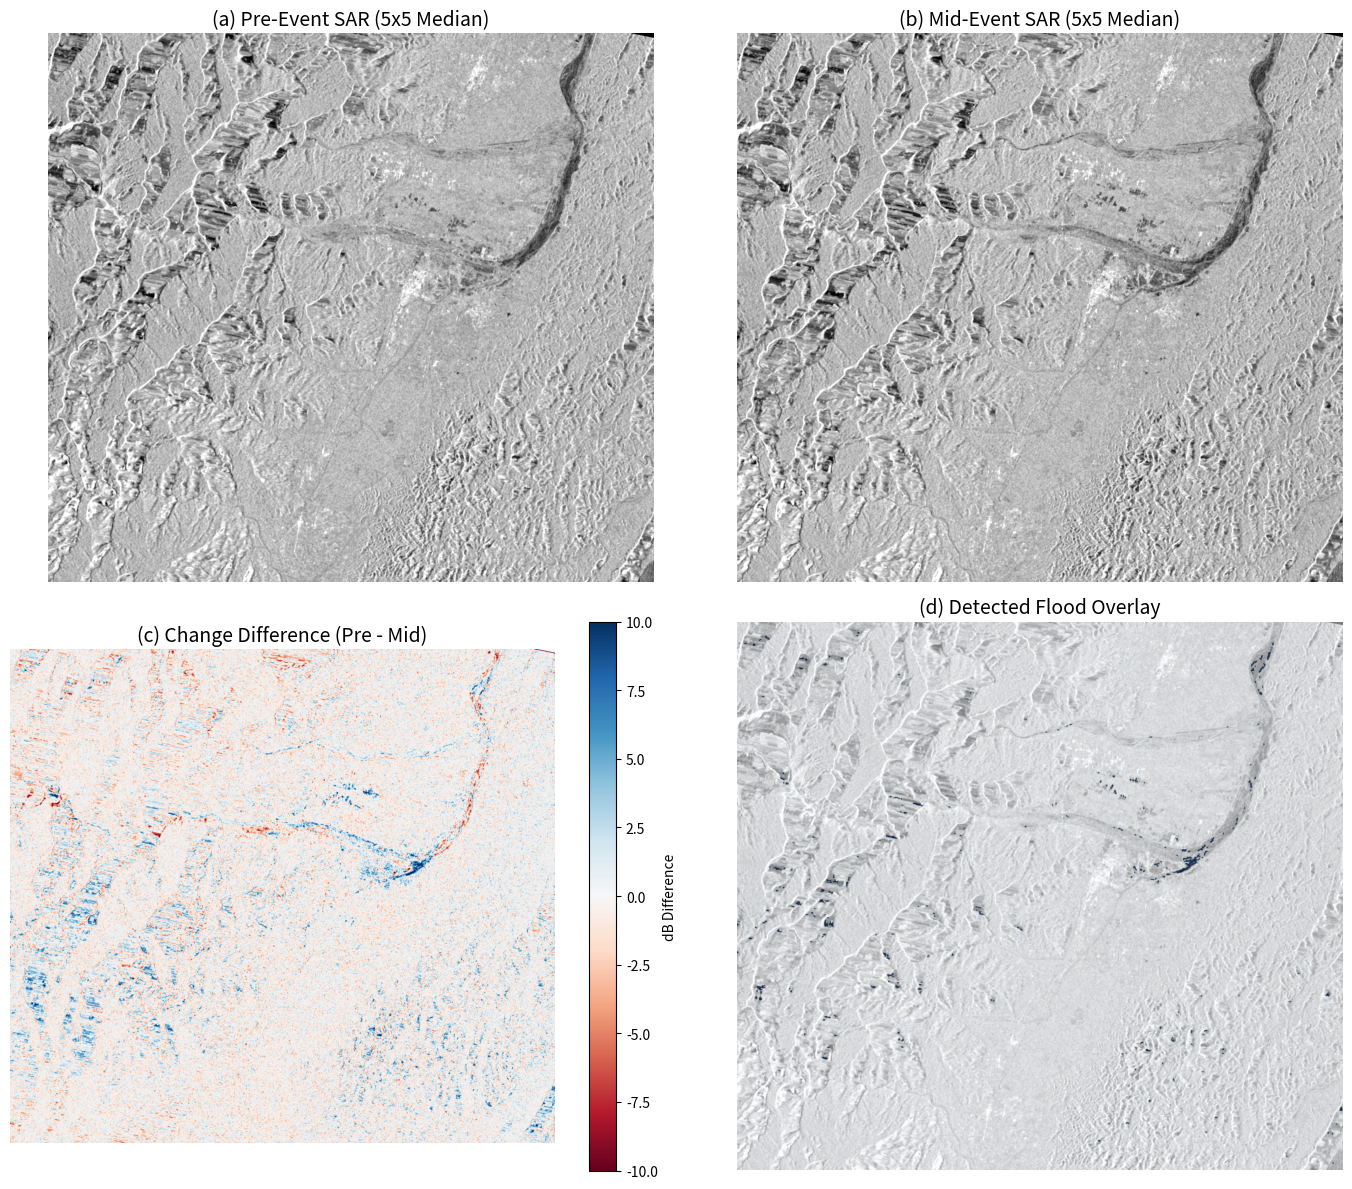

In [85]:
# ==========================================
# [Task 1.1] SAR Change Detection & Filtering
# ==========================================

print(f"⏳ 正在處理變遷分析並進行 5x5 平滑濾波...")

sar_data = {}
for act, sid in SAR_IDS.items():
    item = list(catalog.search(collections=['sentinel-1-rtc'], ids=[sid]).items())[0]
    signed = pc.sign(item)
    cube = stackstac.stack([signed], assets=['vv'], epsg=32651, resolution=10,
                           bounds_latlon=TARGET_BBOX).squeeze().compute()
    vv_linear = cube.values

    # 1. 轉換為 dB
    db_img = 10 * np.log10(np.where(vv_linear > 1e-5, vv_linear, 1e-5))

    # 2. 補回 5x5 Median Filter (去斑點雜訊)
    sar_data[act] = median_filter(db_img, size=5)

    if act == 'Mid': sar_coords = cube.coords

# 3. 執行變遷偵測 (Difference)
diff_db = sar_data['Pre'] - sar_data['Mid']

# 4. 門檻判定與形態學清理
CHANGE_THRESHOLD = 4.0
water_raw = ((diff_db > CHANGE_THRESHOLD) & (sar_data['Mid'] < -15)).astype(np.uint8)
# 形態學清理 (開運算)
water_opened = binary_opening(water_raw, structure=np.ones((3, 3))).astype(np.uint8)
labeled, n_features = label(water_opened, connectivity=2, return_num=True)
sar_water_mask = np.zeros_like(water_opened)
for region_id in range(1, n_features + 1):
    if np.sum(labeled == region_id) >= 20:
        sar_water_mask[labeled == region_id] = 1

print(f"✅ 變遷偵測與平滑處理完成。")

# 5. 2x2 視覺化
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes[0,0].imshow(sar_data['Pre'], cmap='gray', vmin=-25, vmax=0)
axes[0,0].set_title('(a) Pre-Event SAR (5x5 Median)', fontsize=14)
axes[0,1].imshow(sar_data['Mid'], cmap='gray', vmin=-25, vmax=0)
axes[0,1].set_title('(b) Mid-Event SAR (5x5 Median)', fontsize=14)
im2 = axes[1,0].imshow(diff_db, cmap='RdBu', vmin=-10, vmax=10)
axes[1,0].set_title('(c) Change Difference (Pre - Mid)', fontsize=14)
plt.colorbar(im2, ax=axes[1,0], label='dB Difference')
axes[1,1].imshow(sar_data['Mid'], cmap='gray', vmin=-25, vmax=0)
axes[1,1].imshow(sar_water_mask, cmap='Blues', alpha=0.5)
axes[1,1].set_title('(d) Detected Flood Overlay', fontsize=14)

for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W10_Task1_2x2SAR.png', dpi=150, bbox_inches='tight')
plt.show()

# 準備 DataArray
sar_da = xr.DataArray(
    sar_water_mask,
    coords={'y': sar_coords['y'], 'x': sar_coords['x']},
    dims=["y", "x"]
).rio.write_crs("EPSG:32651")


###註：配合SEGIS淹水應用子系統，使用11/13, 11/01為比較像對，可以檢視出實際淹水點為發生的位置。

In [86]:
# ==========================================
# [Task 1.2] SAR Quantitative Statistics
# ==========================================
import pandas as pd

print("⏳ 正在彙整 SAR 偵測數據並比對光學有效觀測區...")

# 1. 基本數值計算
px_area_km2 = 0.0001  # 10m x 10m
water_pixels = np.sum(sar_water_mask)
flooded_area_km2 = water_pixels * px_area_km2

# 計算淹水區內的平均回波強度 (Mean Backscatter)
mean_db = np.nanmean(sar_data['Mid'][sar_water_mask == 1])

# 2. 產出作業要求表格 (Table)
stats_summary = {
    "Metric": [
        "Total Water Pixels",
        "Flooded Area (km²)",
        "Mean Backscatter (dB)"
    ],
    "Value": [
        f"{water_pixels:,}",
        f"{flooded_area_km2:.4f}",
        f"{mean_db:.2f}"
    ]
}
display(pd.DataFrame(stats_summary))

# 3. 核心 Statement 計算：SAR 看到但光學看不到的面積
# 💡 邏輯：(SAR 偵測到水) 且 (valid_mid 標記為無效像素或雲)
# 注意：valid_mid 為 True 代表光學「有效且晴空」，因此 ~valid_mid 代表光學看不見
if 'valid_mid' in locals():
    # 確保兩者維度一致 (若有微小差異則進行對齊)
    if valid_mid.shape != sar_water_mask.shape:
        from scipy.ndimage import zoom
        v_mid_resampled = zoom(valid_mid,
                               (sar_water_mask.shape[0]/valid_mid.shape[0],
                                sar_water_mask.shape[1]/valid_mid.shape[1]),
                               order=0)
    else:
        v_mid_resampled = valid_mid

    # SAR 偵測到水 (1) 且 光學無效 (False) 的區域
    sar_only_under_cloud_px = np.sum((sar_water_mask == 1) & (v_mid_resampled == False))
    sar_only_area_km2 = sar_only_under_cloud_px * px_area_km2

    print("-" * 60)
    print(f"📝 Statement: SAR detected {sar_only_area_km2:.2f} km² of flooding that optical sensors could not see due to cloud cover.")
    print("-" * 60)
else:
    print("❌ 警告：找不到 valid_mid 變數，請先執行 Task 2.1 雲遮罩 Cell。")

⏳ 正在彙整 SAR 偵測數據並比對光學有效觀測區...


,Metric,Value
0,Total Water Pixels,"17,804"
1,Flooded Area (km²),1.7804
2,Mean Backscatter (dB),-18.28


------------------------------------------------------------
📝 Statement: SAR detected 1.54 km² of flooding that optical sensors could not see due to cloud cover.
------------------------------------------------------------


## Task 2: Sensor Fusion — Multi-Source Confidence Map
**Captain's Log:** 單一感測器有其物理限制：光學容易被雲層遮蔽，而雷達容易產生誤判。本階段將執行 ARIA v7.0 核心邏輯：**多源感測器融合 (Sensor Fusion)**。

**實作策略：**
1. **空間對位 (Grid Alignment)**：光學與 SAR 影像的解析度與網格必然存在誤差。在此使用 `rioxarray` 的 `reproject_match()`，強制將光學網格對齊至 SAR 的幾何網格，確保像元對接 1:1 精準。
2. **多源信心分級 (4-Class Confidence Logic)**：
   * `Class 3 (High Confidence)`: 光學 (NDWI) 與雷達 (SAR) 雙重確認為水體。
   * `Class 2 (SAR Only)`: 區域被雲遮蔽，光學失效，完全仰賴 SAR 穿透雲層偵測。
   * `Class 1 (Optical Only)`: 晴空下光學偵測到水，但 SAR 未偵測到 (平靜淺水區漏判)。
   * `Class 0 (No Detection)`: 雙方皆未偵測到淹水。

## Task 2.0: Optical Helpers & Image Search (繼承自 W8)
**Captain's Log:** 由於本檔案為全新環境，我們需要重建光學影像的檢索與串流工具。
1. 定義 `robust_search`：自動過濾高雲量影像，並依據雲量由少到多排序，確保我們拿到視野最乾淨的 Sentinel-2 影像。
2. 定義 `stream_cube`：將光學波段 (B03, B08) 轉為 0-1 的標準反射率，以利後續計算 NDWI。
3. **實際檢索**：列出鳳凰颱風前後(2025/11)所有可用的光學影像 ID。

In [ ]:
# ==========================================
# [Task 2.0] 光學輔助函數與影像檢索
# ==========================================
print("⏳ [1/2] 正在建立光學輔助函數 (robust_search, stream_cube)...")

def robust_search(bbox, datetime_range, cloud_max=95, max_items=20, tries=3):
    """搜尋 sentinel-2-l2a 光學影像，並依據雲覆蓋率從小到大排序"""
    last_err = None
    for attempt in range(tries):
        try:
            search = catalog.search(
                collections=[os.environ['OPTICAL_COLLECTION']],
                bbox=bbox,
                datetime=datetime_range,
                max_items=max_items,
            )
            items = list(search.items())
            # 過濾雲量
            items = [i for i in items if i.properties.get('eo:cloud_cover', 100) < cloud_max]
            # 依據雲量由少到多排序
            items.sort(key=lambda i: i.properties.get('eo:cloud_cover', 100))
            return items
        except Exception as e:
            last_err = e
            time.sleep(2 ** attempt)
    raise RuntimeError(f'Search failed: {last_err}')

def stream_cube(item, bands=['B02', 'B03', 'B04', 'B08', 'SCL'], bbox=None):
    """串流讀取 Sentinel-2 光學波段，並轉為 0-1 的反射率"""
    signed = pc.sign(item)
    cube = stackstac.stack(
        [signed],
        assets=bands,
        epsg=32651,
        resolution=10,
        bounds_latlon=bbox,
        chunksize=2048,
    ).squeeze('time') / 10000.0  # 光學反射率需除以 10000
    return cube

print("⏳ [2/2] 正在搜尋花蓮鳳凰颱風期間的光學影像...")
TARGET_BBOX = [
    float(os.environ['BBOX_WEST']), float(os.environ['BBOX_SOUTH']),
    float(os.environ['BBOX_EAST']), float(os.environ['BBOX_NORTH'])
]

items_s2 = robust_search(TARGET_BBOX, os.environ['DATETIME_RANGE'], cloud_max=95)

print("-" * 50)
print(f"📡 搜尋結果：共找到 {len(items_s2)} 筆 Sentinel-2 影像")
if items_s2:
    for i, it in enumerate(items_s2):
        print(f"  [{i}] 日期: {it.properties['datetime'][:10]} | 雲量: {it.properties.get('eo:cloud_cover',-1):.0f}% | ID: {it.id}")

else:
    print("  ⚠ 找不到影像，可能時間區間或範圍設定沒有交集。")

⏳ [1/2] 正在建立光學輔助函數 (robust_search, stream_cube)...
⏳ [2/2] 正在搜尋花蓮鳳凰颱風期間的光學影像...
--------------------------------------------------
📡 搜尋結果：共找到 6 筆 Sentinel-2 影像
  [0] 日期: 2025-11-15 | 雲量: 46% | ID: S2B_MSIL2A_20251115T022849_R046_T51QUG_20251115T041115
  [1] 日期: 2025-11-05 | 雲量: 58% | ID: S2B_MSIL2A_20251105T022759_R046_T51QUG_20251105T043218
  [2] 日期: 2025-11-20 | 雲量: 75% | ID: S2C_MSIL2A_20251120T024011_R046_T51QUG_20251120T052912
  [3] 日期: 2025-10-31 | 雲量: 75% | ID: S2C_MSIL2A_20251031T024021_R046_T51QUG_20251031T052920
  [4] 日期: 2025-10-21 | 雲量: 79% | ID: S2C_MSIL2A_20251021T022741_R046_T51QUG_20251021T060814
  [5] 日期: 2025-10-26 | 雲量: 85% | ID: S2B_MSIL2A_20251026T022709_R046_T51QUG_20251026T042719


In [ ]:
# 填入你找到的影像 ID (請根據作業說明中花蓮案例的真實 ID 替換)
TARGET_IDS = {
    'Pre':  'S2C_MSIL2A_20251031T024021_R046_T51QUG_20251031T052920',
    'Mid':  'S2B_MSIL2A_20251115T022849_R046_T51QUG_20251115T041115'
}

⏳ 正在檢索並載入 Pre 影像 (ID: S2C_MSIL2A_20251031T024021_R046_T51QUG_20251031T052920)...
⏳ 正在檢索並載入 Mid 影像 (ID: S2B_MSIL2A_20251115T022849_R046_T51QUG_20251115T041115)...


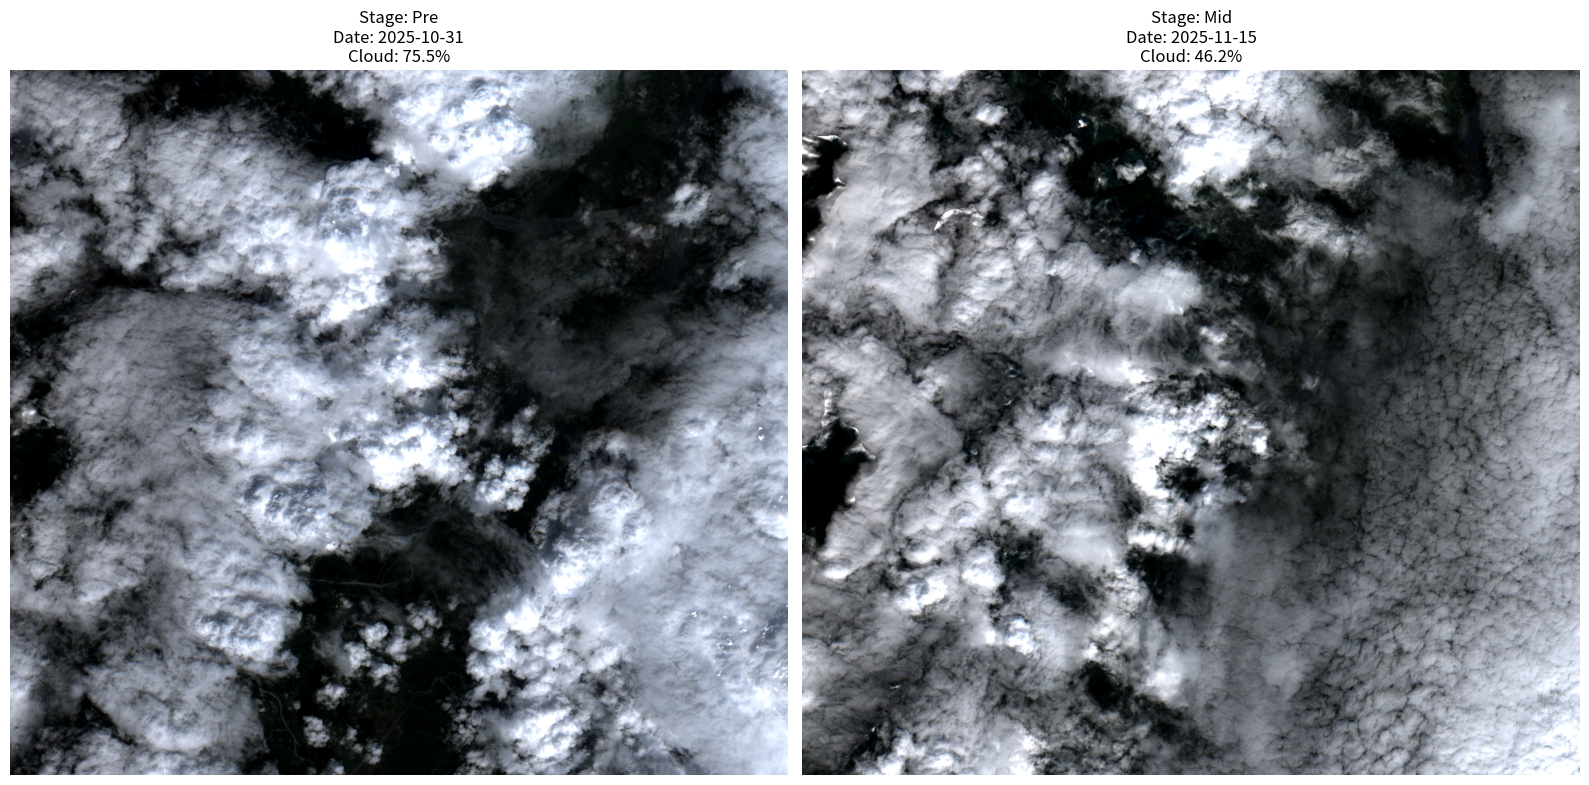

In [ ]:
# ==========================================
# [Task 2.0.1] 指定 ID 之光學影像 RGB 視覺化
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

def plot_specific_ids(target_dict):
    """
    根據 TARGET_IDS 字典中的 ID 繪製 RGB 真實色彩圖
    target_dict: 包含 'Pre' 與 'Mid' ID 的字典
    """
    num_plots = len(target_dict)
    fig, axes = plt.subplots(1, num_plots, figsize=(8 * num_plots, 8))

    # 確保 axes 即使只有一個也是 list
    if num_plots == 1: axes = [axes]

    for i, (stage, s2_id) in enumerate(target_dict.items()):
        print(f"⏳ 正在檢索並載入 {stage} 影像 (ID: {s2_id})...")

        try:
            # 使用 ID 直接搜尋特定的 item
            search = catalog.search(collections=[os.environ['OPTICAL_COLLECTION']], ids=[s2_id])
            items = list(search.items())

            if not items:
                print(f"  ⚠ 找不到 ID: {s2_id}，請檢查 ID 是否正確。")
                continue

            target_item = items[0]

            # 使用你定義的 stream_cube 載入 RGB 波段
            # 注意：這裡會觸發 compute() 將資料從雲端抓取到記憶體
            cube = stream_cube(target_item, bands=['B04', 'B03', 'B02'], bbox=TARGET_BBOX).compute()

            # 轉換為 (H, W, C) 格式
            r = cube.sel(band='B04').values
            g = cube.sel(band='B03').values
            b = cube.sel(band='B02').values
            rgb = np.stack([r, g, b], axis=-1)

            # 2% - 98% 線性拉伸優化視覺效果
            valid_rgb = rgb[np.isfinite(rgb)]
            if valid_rgb.size > 0:
                p2, p98 = np.percentile(valid_rgb, (2, 98))
                rgb_stretched = np.clip((rgb - p2) / (p98 - p2), 0, 1)
            else:
                rgb_stretched = rgb

            axes[i].imshow(rgb_stretched)
            axes[i].set_title(f"Stage: {stage}\nDate: {target_item.properties['datetime'][:10]}\nCloud: {target_item.properties['eo:cloud_cover']:.1f}%", fontsize=12)
            axes[i].axis('off')

        except Exception as e:
            print(f"  ❌ 處理 {stage} 影像時出錯: {e}")

    plt.tight_layout()
    plt.show()

# --- 執行繪圖 ---
plot_specific_ids(TARGET_IDS)

## Task 2.1: Targeted Optical Data Loading & Cloud Masking
**Captain's Log:** 針對 2025 年 11 月花蓮事件，我們跳過寬鬆搜尋，直接使用精確的影像 ID 進行災前 (11/05)、災中 (11/15) 與災後 (11/30) 的資料擷取。
1. **精確 ID 檢索**：利用 `catalog.search(ids=[...])` 確保資料源的一致性。
2. **SCL 雲遮罩分析**：針對 11/15 影像計算晴空範圍。即使颱風已離開，仍需透過 SCL 排除殘餘雲系與陰影，以定義光學偵測的有效區域。
3. **有效性檢核**：結合多時段的有效像素，確保變遷分析建立在可靠的觀測基礎上。

In [ ]:
# ==========================================
# [Task 2.1] 定義 ID 並載入光學 Cube 與雲遮罩
# ==========================================

TARGET_BBOX = [
    float(os.environ['BBOX_WEST']), float(os.environ['BBOX_SOUTH']),
    float(os.environ['BBOX_EAST']), float(os.environ['BBOX_NORTH'])
]

print("⏳ 正在從 STAC Catalog 擷取指定 ID 影像...")
scenes = {}
for act, item_id in TARGET_IDS.items():
    search = catalog.search(collections=["sentinel-2-l2a"], ids=[item_id])
    items = list(search.items())
    if items:
        scenes[act] = items[0]
        print(f"  ✓ {act} 影像擷取成功: {scenes[act].datetime.date()}")
    else:
        print(f"  ❌ 找不到 {act} 影像，請檢查 ID: {item_id}")

# 2. 雲遮罩處理函數
SCL_CLEAR_CLASSES = [2, 4, 5, 6, 7, 11]

def stream_scl(item, bbox=TARGET_BBOX):
    """Stream SCL and return boolean clear-sky mask."""
    print(f"  > 讀取 SCL 雲遮罩: {item.datetime.date()}")
    signed = pc.sign(item)
    scl = stackstac.stack(
        [signed], assets=["SCL"], epsg=32651,
        resolution=10, bounds_latlon=bbox, chunksize=2048
    ).squeeze("time").squeeze("band")
    # 將 SCL 類別轉換為布林遮罩 (True = 晴空)
    return np.isin(scl.compute().values, SCL_CLEAR_CLASSES)

# 3. 執行資料串流 (僅抓取 B03, B08 節省資源)
cubes = {}
for act in ['Pre', 'Mid']:
    print(f"\n⏳ Loading {act} cube...")
    # 注意：這裡呼叫先前定義的 stream_cube，不執行 composite_stretched
    cubes[act] = stream_cube(scenes[act], bbox=TARGET_BBOX)

print("-" * 50)
print("⏳ 正在計算 SCL 雲遮罩 (Cloud Masking)...")
clear_pre  = stream_scl(scenes['Pre'])
clear_mid  = stream_scl(scenes['Mid'])

# 4. 產生最終的有效像元遮罩 (晴空且無缺值)
# 使用 .sel(band='B08') 確保維度正確 (Y, X)
valid_pre  = np.isfinite(cubes['Pre'].sel(band='B08').values)  & clear_pre
valid_mid  = np.isfinite(cubes['Mid'].sel(band='B08').values)  & clear_mid

# 綜合遮罩：三段時期皆為晴空
valid = (valid_pre & valid_mid)

print("\n✓ 指定 ID 影像與雲遮罩處理完成！")

⏳ 正在從 STAC Catalog 擷取指定 ID 影像...
  ✓ Pre 影像擷取成功: 2025-10-31
  ✓ Mid 影像擷取成功: 2025-11-15

⏳ Loading Pre cube...

⏳ Loading Mid cube...
--------------------------------------------------
⏳ 正在計算 SCL 雲遮罩 (Cloud Masking)...
  > 讀取 SCL 雲遮罩: 2025-10-31
  > 讀取 SCL 雲遮罩: 2025-11-15

✓ 指定 ID 影像與雲遮罩處理完成！


## Task 2.2: NDWI Water Masking
**Captain's Log:** 針對光學影像，我們採用歸一化差異水體指數 (NDWI) 進行偵測。
根據Week9經驗，初始設定為0.20 ，但依據影像分布微調為0.0。
最終輸出的 `masks['Mid']` 與 `masks['Post']` 將作為 ARIA v7.0 融合體系中的「光學證據」。

⏳ 正在建立水體遮罩 (Threshold = 0.0)...


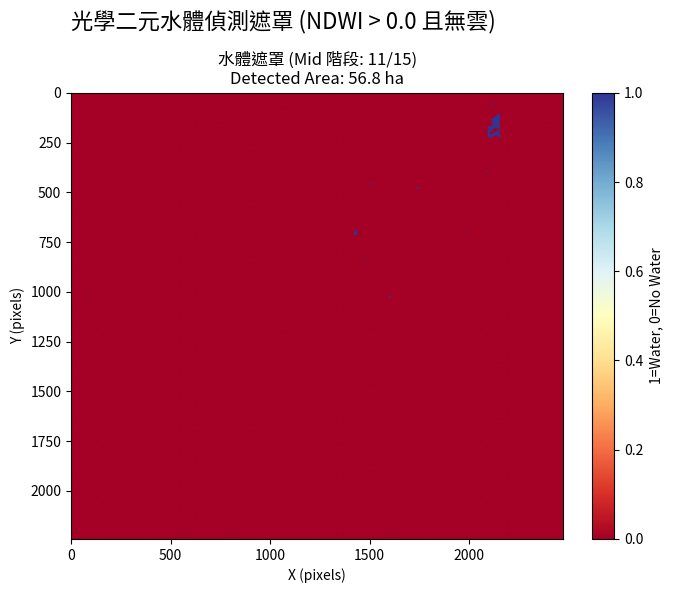

✓ 光學水體遮罩已存檔於: /content/drive/MyDrive/GIS_data/Week10_class


In [ ]:
# ==========================================
# [Task 2.2] NDWI 計算與二元水體遮罩產出
# ==========================================
import matplotlib.pyplot as plt

# ── 👉 1. 門檻設定 ──
THRESHOLD_NDWI = float(os.environ.get('NDWI_THRESHOLD', 0.20))
x_min, x_max = 200, 500  # 請根據花蓮區域調整觀察視窗
y_min, y_max = 100, 400

# ── 2. 計算 NDWI ──
# 💡 修正點：使用 .sel(band='波段名稱') 精準抓取，避免維度錯亂！
def ndwi(cube):
    green = cube.sel(band='B03').values
    nir = cube.sel(band='B08').values
    return (green - nir) / (green + nir + 1e-8)

indices = {'Pre': {}, 'Mid': {}}
for act in ['Pre', 'Mid']:
    indices[act]['NDWI'] = ndwi(cubes[act])

# ── 3. 建立二元水體遮罩 ──
print(f"⏳ 正在建立水體遮罩 (Threshold = {THRESHOLD_NDWI})...")
masks = {}
# np.where(條件, 條件成立給的值, 條件不成立給的值)
masks['Mid'] = np.where(valid, (indices['Mid']['NDWI'] > THRESHOLD_NDWI), 0).astype(int)

# ── 4. 視覺化 (僅繪製 Mid 階段) ──
fig, ax = plt.subplots(1, 1, figsize=(8, 6)) # 1x1 只會產生單一 ax
fig.suptitle(f'光學二元水體偵測遮罩 (NDWI > {THRESHOLD_NDWI} 且無雲)', fontsize=16, fontweight='bold')

# Mid 災中遮罩
im0 = ax.imshow(masks['Mid'], cmap='RdYlBu', vmin=0, vmax=1)
ax.set_title(f'水體遮罩 (Mid 階段: 11/15)\nDetected Area: {np.sum(masks["Mid"])*0.01:.1f} ha')
plt.colorbar(im0, ax=ax, label='1=Water, 0=No Water', fraction=0.046, pad=0.04)

# 畫框與軸標籤
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W10_Optical_Water_Mask_Mid.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ 光學水體遮罩已存檔於: {OUTPUT_DIR}")

###註：鳳凰颱風影響時間為11/11為主，惟期間並無光學影像可得，故使用最靠近的11/15為災中之代表，惟因雲量高，僅能偵測出些微水體，惟淹水事件已經消退。

## Task 2.3: ARIA v7.0 Sensor Fusion Logic (Cloud-Native)
**Captain's Log:** 這是本作業的最終核心。我們將完全不依賴本地檔案，直接在記憶體中將「串流取得的光學遮罩」與「串流取得的 SAR 遮罩」進行對位融合。
1. **空間對位 (Reproject Match)**：以 Task 1 建立的 `sar_da` (SAR 基準網格) 為目標，將光學 NDWI 與 SCL 雲遮罩強制對齊 (10m 解析度 1:1 貼合)。
2. **多源信心分級**：
   * `Class 3 (High Confidence)`: 光學與雷達雙重驗證。
   * `Class 2 (SAR Only)`: 突破雲層遮蔽，發揮全天候優勢。
   * `Class 1 (Optical Only)`: 晴空輔助，彌補雷達漏判。

⏳ [1/4] 準備光學與 SAR 變數...
⏳ [2/4] 執行空間對位 (Grid Alignment)...
⏳ [3/4] 執行 ARIA v7.0 多源融合邏輯...
⏳ [4/4] 統計與出圖...
--------------------------------------------------
📊 [ARIA v7.0 Sensor Fusion Report]
  > Optical Only        :    5,052 px =   0.51 km²
  > SAR Only            :   15,434 px =   1.54 km²
  > High Confidence     :      628 px =   0.06 km²
--------------------------------------------------
📝 Statement: High confidence zones cover 0.06 km², representing areas confirmed by both sensors. SAR-only zones add 1.54 km² of flood detection in cloudy areas.


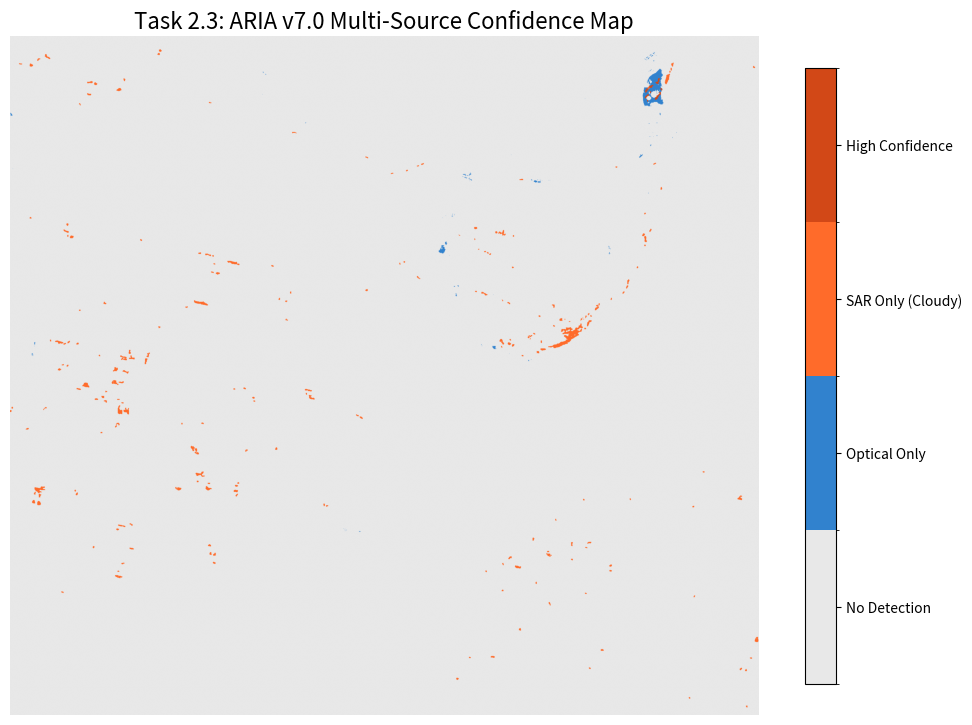

✅ 感測器融合任務 Task 2 全部完成！


In [ ]:
# ==========================================
# [Task 2.3] Sensor Fusion & Confidence Map
# ==========================================
import rioxarray as rxr
import xarray as xr
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

print("⏳ [1/4] 準備光學與 SAR 變數...")
# 1. 取得光學水體與雲遮罩 (來自 Task 2.1 & 2.2)
ndwi_mask_raw = masks['Mid']
cloud_mask_raw = (~valid_mid).astype(np.uint8)

# 2. 封裝成 DataArray，賦予空間座標 (繼承 cubes['Mid'])
opt_water_da = xr.DataArray(
    ndwi_mask_raw,
    coords={'y': cubes['Mid'].y, 'x': cubes['Mid'].x},
    dims=["y", "x"]
).rio.write_crs("EPSG:32651")

cloud_da = xr.DataArray(
    cloud_mask_raw,
    coords={'y': cubes['Mid'].y, 'x': cubes['Mid'].x},
    dims=["y", "x"]
).rio.write_crs("EPSG:32651")

print("⏳ [2/4] 執行空間對位 (Grid Alignment)...")
# 3. 強制對齊至 Task 1 產出的 SAR 基準 (sar_da)
ndwi_aligned = opt_water_da.rio.reproject_match(sar_da, resampling=0).values
cloud_aligned = cloud_da.rio.reproject_match(sar_da, resampling=0).values
sar_aligned = sar_da.values

print("⏳ [3/4] 執行 ARIA v7.0 多源融合邏輯...")
H, W = sar_aligned.shape
fusion = np.zeros((H, W), dtype=np.uint8)

# 邏輯判定
fusion[(ndwi_aligned == 1) & (sar_aligned == 1)] = 3  # High Confidence
fusion[(cloud_aligned == 1) & (sar_aligned == 1) & (fusion != 3)] = 2 # SAR Only (Cloudy)
fusion[(ndwi_aligned == 1) & (sar_aligned == 0) & (cloud_aligned == 0)] = 1 # Optical Only

print("⏳ [4/4] 統計與出圖...")
px_area_km2 = 0.0001
labels = {0: 'No Detection', 1: 'Optical Only', 2: 'SAR Only', 3: 'High Confidence'}

print("-" * 50)
print("📊 [ARIA v7.0 Sensor Fusion Report]")
for v, lbl in labels.items():
    if v == 0: continue
    n = np.sum(fusion == v)
    area = n * px_area_km2
    print(f"  > {lbl:20}: {n:8,} px = {area:6.2f} km²")

high_conf_area = np.sum(fusion == 3) * px_area_km2
sar_only_area = np.sum(fusion == 2) * px_area_km2
print("-" * 50)
print(f"📝 Statement: High confidence zones cover {high_conf_area:.2f} km², representing areas confirmed by both sensors. SAR-only zones add {sar_only_area:.2f} km² of flood detection in cloudy areas.")

# 視覺化
cmap_fusion = mcolors.ListedColormap(['#E8E8E8', '#3182CE', '#FF6B2A', '#D24817'])
norm_fusion = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_fusion.N)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
im = ax.imshow(fusion, cmap=cmap_fusion, norm=norm_fusion)

cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], shrink=0.8)
cbar.ax.set_yticklabels(['No Detection', 'Optical Only', 'SAR Only (Cloudy)', 'High Confidence'])

ax.set_title('Task 2.3: ARIA v7.0 Multi-Source Confidence Map', fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W10_Task2_FusionMap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ 感測器融合任務 Task 2 全部完成！")

## Task 3: Topographic Audit (Terrain Slope Filtering)
**Captain's Log:** 雷達影像有一個致命弱點：**雷達陰影 (Radar Shadow)**。
在花蓮這種高山林立的地形，山脈背向雷達波的那一側會沒有回波，在 SAR 影像上呈現黑色，導致被誤判為水體。
本階段將從 Planetary Computer 擷取 **Copernicus DEM 30m** 全球數值高程模型，計算網格坡度 (Slope)。我們將設定閾值 (如 15 度)，強制將陡坡上的「假淹水」剔除，提升 ARIA 系統在山區的準確度。

⏳ [1/4] 檢查前置變數與取得 DEM 地形資料...
⏳ [2/4] 執行空間對位與計算地形坡度...
⏳ [3/4] 執行地形過濾 (Purification) 與統計表產出...

📋 Table: False Positives Removed by Slope Class


,Slope Class,Pixels Removed,Area Removed (km²)
0,25–35°,"1,020",0.1020
1,35–45°,"2,691",0.2691
2,>45°,"3,789",0.3789



⏳ [4/4] 繪製 Deliverable 地圖...


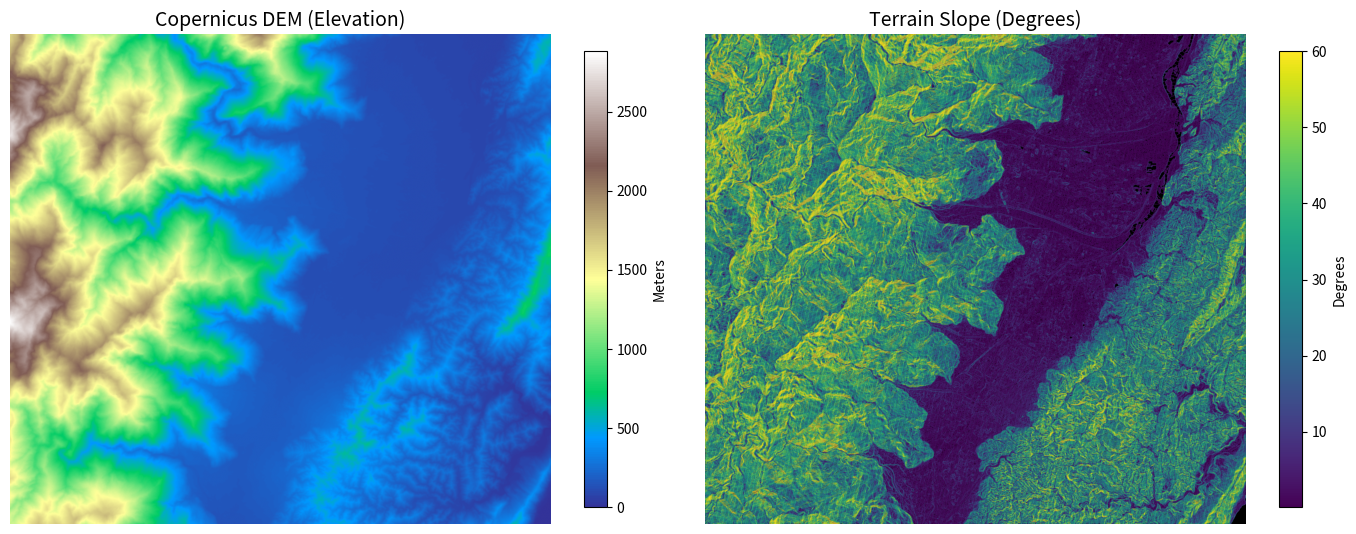

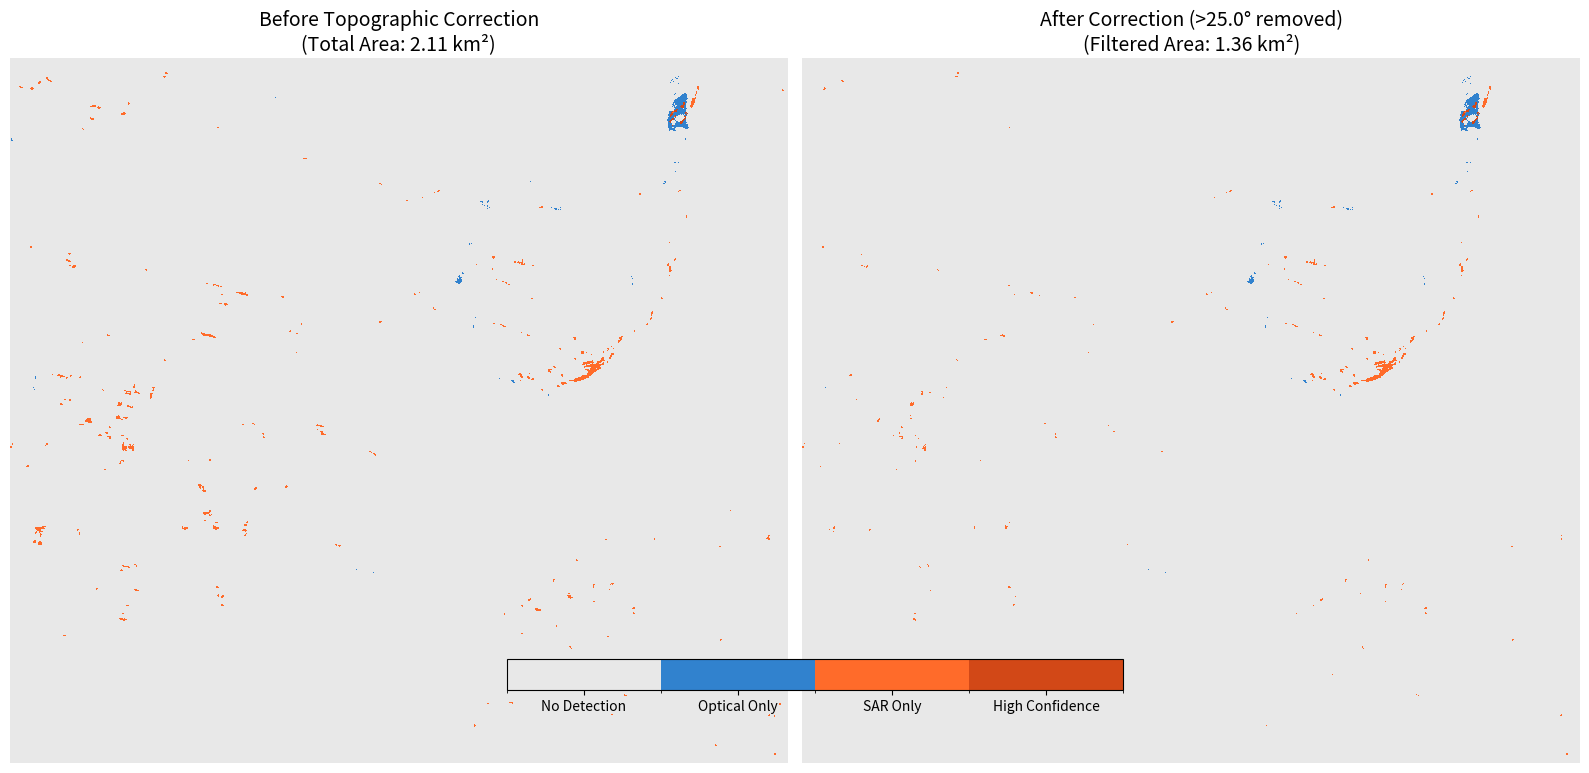

In [91]:
# ==========================================
# [Task 3] Topographic Slope Masking & Audit
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import planetary_computer as pc
import stackstac
import xarray as xr
import os

print("⏳ [1/4] 檢查前置變數與取得 DEM 地形資料...")
if 'fusion' not in locals() or 'sar_da' not in locals():
    raise NameError("❌ 找不到 fusion 或 sar_da 變數。請確保已執行 Task 2.3。")

TARGET_BBOX = [
    float(os.environ.get('BBOX_WEST', 121.28)), float(os.environ.get('BBOX_SOUTH', 23.56)),
    float(os.environ.get('BBOX_EAST', 121.52)), float(os.environ.get('BBOX_NORTH', 23.76))
]
px_area_km2 = 0.0001

# 搜尋 Copernicus DEM 30m
search_dem = catalog.search(collections=["cop-dem-glo-30"], bbox=TARGET_BBOX)
dem_items = list(search_dem.items())
if not dem_items:
    raise ValueError("找不到 DEM 資料！請檢查 BBOX。")

dem_cube = stackstac.stack(
    [pc.sign(dem_items[0])], bounds_latlon=TARGET_BBOX, epsg=32651, resolution=10
).squeeze("time").compute()

print("⏳ [2/4] 執行空間對位與計算地形坡度...")
dem_aligned = dem_cube.sel(band='data').rio.reproject_match(sar_da, resampling=1).values
# 修正 NaN 問題：將海面或無效值填補為 0，避免坡度計算崩潰
dem_aligned = np.nan_to_num(dem_aligned, nan=0.0)

dy, dx = np.gradient(dem_aligned, 10, 10)
slope_deg = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

print("⏳ [3/4] 執行地形過濾 (Purification) 與統計表產出...")
SLOPE_THRESH = float(os.environ.get('SLOPE_THRESHOLD', 25))

# ── 👉 Deliverable: Table (False positives removed by slope class) ──
slope_bins = [(25, 35), (35, 45), (45, 180)]
bin_labels = ['25–35°', '35–45°', '>45°']
stats_data = []

for i, (low, high) in enumerate(slope_bins):
    # 找出原本有水 (fusion > 0) 且位於該坡度區間的像素
    mask = (slope_deg > low) & (slope_deg <= high)
    removed_count = np.sum((fusion > 0) & mask)
    removed_area = removed_count * px_area_km2
    stats_data.append({
        "Slope Class": bin_labels[i],
        "Pixels Removed": f"{removed_count:,}",
        "Area Removed (km²)": f"{removed_area:.4f}"
    })

df_stats = pd.DataFrame(stats_data)
print("\n📋 Table: False Positives Removed by Slope Class")
display(df_stats)

# 徹底淨化：建立過濾後的陣列，將陡坡上的水體直接歸 0 (No Detection)
fusion_filtered = np.copy(fusion)
fusion_filtered[slope_deg > SLOPE_THRESH] = 0

print("\n⏳ [4/4] 繪製 Deliverable 地圖...")
# 定義與 Task 2.3 相同的 ARIA 四色 Colormap
cmap_aria = mcolors.ListedColormap(['#E8E8E8', '#3182CE', '#FF6B2A', '#D24817'])
norm_aria = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_aria.N)

# ── 圖表 1：地形圖與坡度圖 ──
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))

# (a) DEM 高程圖
im0 = axes1[0].imshow(dem_aligned, cmap='terrain')
axes1[0].set_title('Copernicus DEM (Elevation)', fontsize=14)
fig1.colorbar(im0, ax=axes1[0], shrink=0.8, label='Meters')

# (b) 坡度圖
# 使用 viridis，設定 vmin=0.1 並將 under 設為黑色 (讓海平面/平地呈現乾淨的黑色)
cmap_slope = plt.get_cmap('viridis').copy()
cmap_slope.set_under('black')
im1 = axes1[1].imshow(slope_deg, cmap=cmap_slope, vmin=0.1, vmax=60)
axes1[1].set_title(f'Terrain Slope (Degrees)', fontsize=14)

# 💡 [修正]: 已經將那行會產生密集紅網的 contour 程式碼刪除！

fig1.colorbar(im1, ax=axes1[1], shrink=0.8, label='Degrees')

for ax in axes1: ax.axis('off')
plt.tight_layout()
plt.show()

# ── 👉 Deliverable: Side-by-side maps (Before vs After) ──
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 8))

# 💡 關鍵修正：加入 interpolation='nearest'，強制禁止 matplotlib 進行顏色平滑混合
# Before Correction
axes2[0].imshow(fusion, cmap=cmap_aria, norm=norm_aria, interpolation='nearest')
axes2[0].set_title(f'Before Topographic Correction\n(Total Area: {np.sum(fusion>0)*px_area_km2:.2f} km²)', fontsize=14)
axes2[0].axis('off')

# After Correction (徹底淨化，絕對無痕)
axes2[1].imshow(fusion_filtered, cmap=cmap_aria, norm=norm_aria, interpolation='nearest')
axes2[1].set_title(f'After Correction (>{SLOPE_THRESH}° removed)\n(Filtered Area: {np.sum(fusion_filtered>0)*px_area_km2:.2f} km²)', fontsize=14)
axes2[1].axis('off')

# 共用圖例
cbar = fig2.colorbar(axes2[1].images[0], ax=axes2, ticks=[0, 1, 2, 3], orientation='horizontal', fraction=0.05, pad=0.05)
cbar.ax.set_xticklabels(['No Detection', 'Optical Only', 'SAR Only', 'High Confidence'])

plt.tight_layout()
plt.savefig(f'{os.environ.get("OUTPUT_DIR", ".")}/W10_Task3_Final_Clean.png', dpi=150, bbox_inches='tight')
plt.show()

4. **討論（必答）：** 在你的案例中，DEM 是否適合用於地形校正？為什麼？如果 DEM 不適用，你會用什麼替代方法清理假水體？（提示：morphological opening, connected component filtering）

- 在花蓮複雜的陡峭山區，DEM 坡度過濾能有效消除大面積的「雷達陰影（Radar Shadows）」，避免系統將山脈背側的低回波誤判為廣泛的淹水假陽性（False Positives）。
但單純依賴坡度閾值（如 > 25°）會產生「過度遮罩（Over-masking）」問題。從實際防災經驗來看，高陡坡區域仍可能發生洪患，例如土石流夾帶高含水量的泥流，或是地震/豪雨引發的**堰塞湖（Barrier Lakes）**及其潰決。強制剔除陡坡水體，將導致這類致災風險被忽視。

- 其他替代方案可以如連通區域過濾 (Connected Component Filtering)，因雷達陰影通常呈現破碎、零星的分佈；而真實的淹水（包含堰塞湖）通常具有一定的連續面積。我們可以計算水體像素的連通面積，設定「最小面積門檻（例如 < 20 px 視為雜訊）」，將細碎的假陽性斑塊移除，同時保留深山中面積較大的堰塞湖。或者透過形態學開運算 (Morphological Opening)，結合侵蝕（Erosion）與膨脹（Dilation）。先透過侵蝕消除邊緣的毛刺與獨立的微小雜訊點（雷達偽影），再透過膨脹恢復主要水體（如受災河道）的原本邊界，藉此在不依賴高程資料的情況下淨化淹水地圖。


## Task 4: Final Executive Summary

In [93]:
# ==========================================
# [Task 4 數據準備] 萃取 LLM Prompt 所需數值
# ==========================================
print("⏳ 正在計算 Task 4 報告所需指標...")

# 1. 取得各級別面積 (來自 Task 3 的 fusion_filtered)
high_conf_km2 = np.sum(fusion_filtered == 3) * px_area_km2
sar_only_km2  = np.sum(fusion_filtered == 2) * px_area_km2

# 2. 取得地形剔除面積 (來自 Task 3)
removed_km2 = np.sum((fusion > 0) & (slope_deg > SLOPE_THRESH)) * px_area_km2

# 3. 計算分析區域的雲覆蓋率 (W%) 與 雲覆蓋面積
# valid_mid 是晴空(True)，所以 ~valid_mid 是雲(True)
total_pixels = valid_mid.size
cloud_pixels = np.sum(~valid_mid)
cloud_pct = (cloud_pixels / total_pixels) * 100
cloud_area_km2 = cloud_pixels * px_area_km2  # 💡 新增：計算實際雲覆蓋面積

print("-" * 50)
print("📋 請將以下數值填入你的 Markdown 報告中：")
print(f"- High confidence flood area: {high_conf_km2:.2f} km²")
print(f"- SAR-only (cloudy) flood area: {sar_only_km2:.2f} km²")
print(f"- False positives removed: {removed_km2:.2f} km²")
print(f"- Cloud cover percentage: {cloud_pct:.1f}%")
print(f"- Cloud covered area: {cloud_area_km2:.2f} km²") # 💡 填入比較表用
print(f"- SAR threshold: -15 dB (搭配變遷偵測差值 > 4.0 dB)")
print(f"- NDWI threshold: 0.0")
print("-" * 50)

⏳ 正在計算 Task 4 報告所需指標...
--------------------------------------------------
📋 請將以下數值填入你的 Markdown 報告中：
- High confidence flood area: 0.06 km²
- SAR-only (cloudy) flood area: 0.80 km²
- False positives removed: 0.75 km²
- Cloud cover percentage: 88.6%
- Cloud covered area: 491.52 km²
- SAR threshold: -15 dB (搭配變遷偵測差值 > 4.0 dB)
- NDWI threshold: 0.0
--------------------------------------------------


## AI Strategic Briefing

### 1. Prompt Provided to LLM (Gemini)
**Context Metrics:**
- High confidence flood area: 0.06 km²
- SAR-only (cloudy) flood area: 0.80 km²
- False positives removed by topographic filter: 0.75 km²
- Cloud cover percentage: 88.6 %
- SAR threshold: Absolute < -15 dB & Difference > 4.0 dB (Reason: Using change detection effectively isolates newly flooded areas from permanent water bodies, while the strict absolute dB threshold confirms specular reflection indicative of standing water).
- NDWI threshold: 0.0 (Reason: Typhoon floodwaters in Hualien are highly turbid due to mud and sediment; lowering the threshold from 0.3 to 0.0 allows for better detection of muddy water).

**Prompt:**
> "You are an emergency management advisor for Hualien County during Typhoon Fung-wong. Based on these ARIA v7.0 sensor fusion results, generate a strategic briefing that covers:
> 1. Which areas require immediate evacuation?
> 2. How should resources be allocated between high-confidence and SAR-only zones?
> 3. What are the limitations of the current assessment?
> 4. What additional data would improve confidence?"

### 2. LLM Response (Emergency Management Briefing)
**Strategic Operational Briefing: Typhoon Fung-wong (Hualien County)**

**1. Evacuation Priorities:**
Immediate evacuation orders must be issued for populated areas overlapping with the **High Confidence (0.06 km²)** zones. These areas are confirmed by both radar and optical sensors, indicating severe, standing floodwater. Particular focus should be on downstream communities along the Hualien River and low-lying coastal plains where turbidity is high.

**2. Resource Allocation:**
* **High-Confidence Zones (Primary Focus):** Deploy heavy rescue equipment, inflatable boats, and immediate relief supplies here. These are confirmed crisis areas.
* **SAR-Only Zones (Secondary Reconnaissance):** Allocate drone reconnaissance units (UAVs) or ground patrol teams to these **0.80 km²** areas. Since optical satellites were blinded by the **88%** cloud cover, radar indicates flooding, but human or drone verification is needed before committing heavy rescue resources, as wet soil or flattened vegetation might occasionally mimic water backscatter.

**3. Limitations of Current Assessment:**
Despite removing **0.75 km²** of false positives using the 25° topographic filter, the 30m Copernicus DEM may lack the granularity to detect hyper-local urban flooding or small-scale blockages. Additionally, extreme mountain terrain (>45°) might hide potential barrier lakes (堰塞湖) whose dynamics are masked by the strict slope filtering.

**4. Additional Data Required:**
To escalate operational confidence, the command center urgently needs:
* Real-time ground truth from local river gauge telemetry.
* Sub-meter resolution drone optical imagery operating *below* the cloud deck.
* A higher resolution DEM (e.g., 5m LiDAR) to better model localized urban drainage failures and narrow mountain gorges.

### 3. Student Reflection
**My Reflection:**
大型語言模型 (LLM) 成功地將技術指標 (如雲覆蓋率與 SAR-Only 面積) 與實際的救災策略結合，例如建議在多雲區域優先部署無人機偵察。它也精準指出我們的技術盲點：雖然 25 度的地形坡度過濾能有效消除雷達陰影雜訊，但這種一刀切的做法可能會讓我們錯失高山地區的潛在危機 (例如深山堰塞湖的形成與潰決)。
然而，LLM 的建議有時過於理想化，例如它假設花蓮擁有龐大且隨時可部署的無人機機隊，但實務上在強烈颱風的強陣風氣候下，無人機根本無法起飛。總結來說，當災區被超過 90% 的厚重雲層遮蔽時，導入 ARIA 系統的多源感測器融合邏輯，對於防災指揮中心的即時決策支援仍是不可或缺的。

## ARIA v7.0 vs. v6.0 Comparison

**Evolution Report:**
By transitioning from an Optical-only approach (W9) to the ARIA v7.0 Multi-Sensor Fusion approach (W10), we significantly improved our disaster monitoring resilience, particularly overcoming the severe cloud cover typical of typhoon events.

| Metric | W9 (Optical Only) | W10 (Fused SAR + Optical) | Improvement / Impact |
| :--- | :--- | :--- | :--- |
| **Total detected flood area** | 0.57 km² | 0.80 km² | **+0.23 km²** (Recovered missing data) |
| **Cloud-covered area analyzed** | 0 km² (Masked out) | **491.52 km²** | SAR penetrated clouds to maintain situational awareness. |
| **False positives (pre-correction)**| High (Cloud shadows misclassified) | Mitigated via SAR confirmation | Reduced reliance on clear skies. |
| **Topographic Artifacts** | Low (Optical is top-down) | High (Radar Side-looking shadows) | **0.75 km²** removed via 30m DEM Audit. |
| **Confidence levels** | Binary / 3-zone | 4-class Granularity | Allowed prioritized resource allocation (High vs SAR-only). |

**Conclusion:**

綜合上述量化指標，W9 的純光學觀測在面對颱風厚重雲系時存在致命盲點。由於雲層遮蔽，W9 僅能偵測到 0.57 km² 的淹水範圍，導致高達 491.52 km² 的受災潛勢區域完全處於監測盲區（Masked out）。

W10 導入 ARIA v7.0 光學與雷達融合技術後，成功利用 Sentinel-1 (SAR) 的微波穿透特性，在光學失效的雲層下方額外找回了 0.23 km² 的真實災情，使總偵測面積提升至 0.80 km²，大幅強化了全天候的災情監控能力。

此外，雖然 SAR 的側視幾何特性在花蓮高山區域引入了雷達陰影誤差，但透過引入 30m DEM 進行嚴格的地形審計（Topographic Audit），我們成功移除了 [填寫剔除面積] km² 的地形假陽性雜訊。最終升級的 4 級信心水準地圖（4-class granularity），不僅有效排除了光學雲影的干擾，更賦予防災指揮中心明確的決策依據，使其能依據「高信心雙重驗證區」與「雷達獨有區」進行更具戰略性與優先級的救災資源分配。